In [1]:
import numpy as np
from numpy.linalg import pinv
from tensorlib.tucker import hosvd
from tensorlib import dtensor, unfolded_dtensor
from tensorlib.tpconvex import to_cno, to_irno
from tensorlib.grid import coordinate_grid, map_points_to_grid
from tensorlib.draw import draw_weighting_system
from tensorlib.inference import reconstruct, infer_ats
from tensorlib.metrics import calc_R2, calc_nRMSE_maxmin, calc_nRMSE_iqr, calc_cindex

###############################################
## Constants, file paths
###############################################
FOLDER = "app_inverted_pendulum"
CSVFILE = f"./{FOLDER}/pendulum_data.csv"

In [2]:
mygrid = coordinate_grid.create_from_polyranges([
    [(-70, -60, 20), (-50, -40, 20), (-35, -25, 20), (-20, -10, 20),
         (-18, -8, 20), (-15, -5, 20), (-13, -3, 20), (-12, -2, 20),
         (-11, -1, 20), (-10, 0, 20), (-9, 1, 20), (-8, 2, 20), (-7, 3, 20),
         (-5, 5, 20), (-2, 8, 20), (0, 10, 20), (15, 25, 20), (30, 40, 20), (50, 60, 20)],
    [(-60, -50, 20), (-45, -35, 20), (-30, -20, 20), (-20, -10, 20),
         (-18, -8, 20), (-15, -5, 20), (-13, -3, 20), (-12, -2, 20), (-11, -1, 20),
         (-10, 0, 20), (-9, 1, 20), (-8, 2, 20), (-7, 3, 20), (-5, 5, 20), (-2, 8, 20),
         (0, 10, 20), (10, 20, 20), (25, 35, 20), (40, 50, 20)]],
    dim_names=['angle', 'angular velocity']
)
print("Coordinates per dimension:\n")
dimnames = mygrid.get_dim_names()
for inx,coords in enumerate(mygrid.get_coords_per_dim()):
    print(f"{dimnames[inx]}: {coords}")
print("")
len1, len2 = len(mygrid.get_coords_per_dim()[0]), len(mygrid.get_coords_per_dim()[1])
print(f"This is a {len1}-by-{len2} dimensional grid")

Coordinates per dimension:

angle: [-60.0, -40.0, -25.0, -10.0, -8.0, -5.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0, 25.0, 40.0, 60.0]
angular velocity: [-50.0, -35.0, -20.0, -10.0, -8.0, -5.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0, 20.0, 35.0, 50.0]

This is a 19-by-19 dimensional grid


In [3]:
import pandas as pd

df = pd.read_csv(CSVFILE, delimiter=',', encoding='utf-8')
df.head()

,angle,angular velocity,force
0,-60.0,-50.0,-7500000.0
1,-60.0,-35.0,-202070.5
2,-60.0,-20.0,-8000000.0
3,-60.0,-10.0,-123785.0
4,-60.0,-8.0,-37500.0


In [4]:
data = dtensor(df)

In [5]:
aggregates, counts = map_points_to_grid(data, mygrid, agg='closest', Pc=1) ## or mean, closest or weighted_sum
aggregates = dtensor(aggregates)
print(counts)

print(f"Sample coordinate: {mygrid.get_grid_with_coords()[0,2]}")
print(f"Count for coordinate: {counts[0,2]}")
print(f"Aggregate for coordinate: {aggregates[0,2]}")
print(f"shape of each data structure: {mygrid.get_grid_with_coords().shape}, {counts.shape}, {aggregates.shape}")

Bucketing all datapoints by gridpoint based on primary associations [#################################################>] 100% | Elapsed: 00h 00m 00s | Remaining: 00h 00m 00s
Bucket further datapoints by gridpoint based on secondary associations (where necessary) [#################################################>] 100% | Elapsed: 00h 00m 00s | Remaining: 00h 00m 00s
Aggregate [#################################################>] 100% | Elapsed: 00h 00m 00s | Remaining: 00h 00m 00s
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1

## Keeping 2 singular values...

In [6]:
IS_TWO_DIMENSIONAL = True

Us, S, eigvals = hosvd(aggregates, with_eigvals=True)

if IS_TWO_DIMENSIONAL:
    print(f"Singular values are: {np.diag(S)}")
    rank_to_keep = int(input("How many singular values do you want to keep?"))
    Us_tilde, S_tilde = hosvd(aggregates, rank=[rank_to_keep]*aggregates.ndim)
else:
    Us, S, eigvals = hosvd(aggregates, with_eigvals=True)
    print("Eigenvalues in each dimension:")
    for inx, eigval in enumerate(eigvals):
        print(f"Dimension {inx+1}: {eigval}")

    decision = input("""
    How many ranks to keep?
    a.)              Same rank in all dimensions
    b.)              Dimension-specific ranks
    c.)              Two ranks in all dimensions
    [anything else]) All ranks in all dimensions

    """)

    if decision == 'a':
        rank_to_keep = int(input("How many singular values do you want to keep?"))
        Us_tilde, S_tilde = hosvd(aggregates, rank=[rank_to_keep]*aggregates.ndim)
    elif decision == 'b':
        ranks_to_keep = [1 for _ in range(aggregates.ndim)]
        for inx in range(aggregates.ndim):
            ranks_to_keep[inx] = int(input(f"How many singular values to keep in dimension {inx+1}?"))
        Us_tilde, S_tilde = hosvd(aggregates, rank=ranks_to_keep)
    elif decision == 'c':
        rank_to_keep = 2
        Us_tilde, S_tilde = hosvd(aggregates, rank=[rank_to_keep]*aggregates.ndim)
    else:
        Us_tilde, S_tilde = hosvd(aggregates)

reconstructed = reconstruct(S_tilde, Us_tilde)
rmse_reconstruction = np.sqrt(np.mean((reconstructed - aggregates)**2))

r2_reconstruction = calc_R2(aggregates, reconstructed)
#c_reconstruction = calc_cindex(aggregates, reconstructed)
print(f"Reconstruction R2 is: {r2_reconstruction}")
#print(f"Reconstruction Concordance index is: {c_reconstruction}")

data_reconstructed = infer_ats(
    S_tilde, Us_tilde, mygrid, data[:,:data.shape[1]-1]
)

nrmse_mmin_dataset = calc_nRMSE_maxmin(data[:, -1].reshape(-1,1), data_reconstructed)
nrmse_iqr_dataset = calc_nRMSE_iqr(data[:, -1].reshape(-1,1), data_reconstructed)
r2_dataset = calc_R2(data[:, -1].reshape(-1,1), data_reconstructed)
c_dataset = calc_cindex(data[:, -1].reshape(-1,1), data_reconstructed)
print(f"Normalized RMSE on original data (dividing by max - min) is: {nrmse_mmin_dataset}")
print(f"Normalized RMSE on original data (dividing by interquartile range) is: {nrmse_iqr_dataset}")
print(f"R2 on original data is: {r2_dataset}")
print(f"Concordance index on original data is: {c_dataset}")


Singular values are: [-2.8517258e+08  8.1193064e+07 -2.8829596e+07 -1.4508145e+07
 -1.2349251e+07 -1.0339120e+07 -8.9297640e+06  8.2822770e+06
  3.0395455e+06  2.4805200e+06  1.4550805e+06 -6.2592981e+05
 -2.5636272e+03 -5.8555920e+02 -3.1084436e+04  1.0135222e+04
  3.7604395e+03  2.0430736e+03 -1.9589629e+02]


How many singular values do you want to keep? 2


Reconstruction R2 is: 0.9835433959960938
Normalized RMSE on original data (dividing by max - min) is: 0.005508383152333182
Normalized RMSE on original data (dividing by interquartile range) is: 443.0919195063614
R2 on original data is: 0.9835434173211396
Concordance index on original data is: 0.8276889815458266


In [7]:
S_cno, Us_cno = to_cno(S_tilde, Us_tilde)

Distance from NO: 7.423922421073693
Distance from NO: 0.048483817255921956


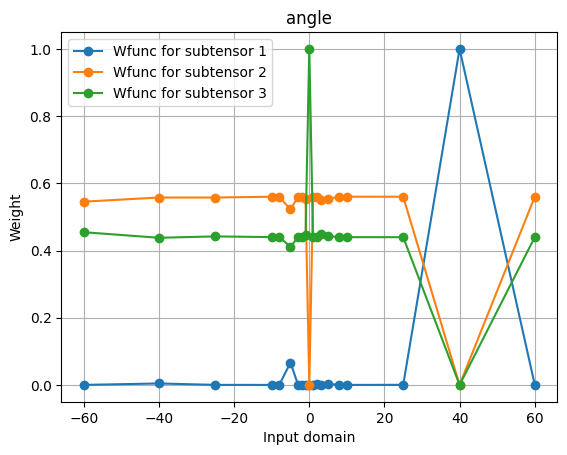

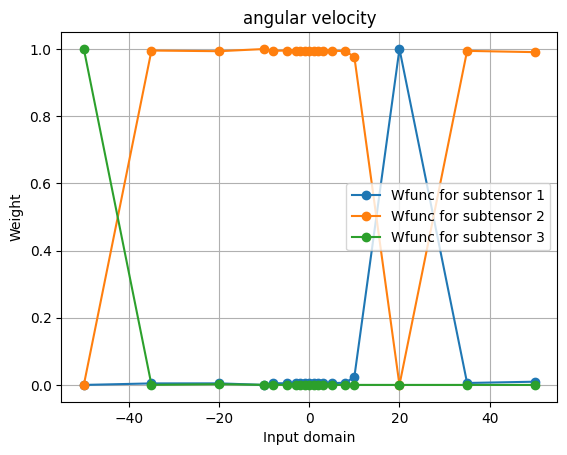

In [8]:
draw_weighting_system(Us_cno, mygrid, save=True, filename="cno_rank2")

In [9]:
S_irno, Us_irno = to_irno(S_tilde, Us_tilde)

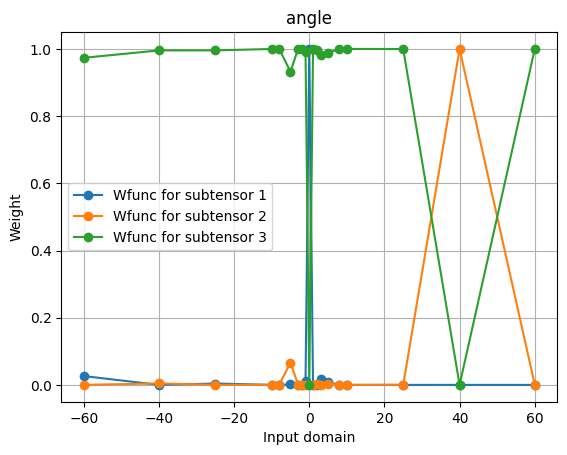

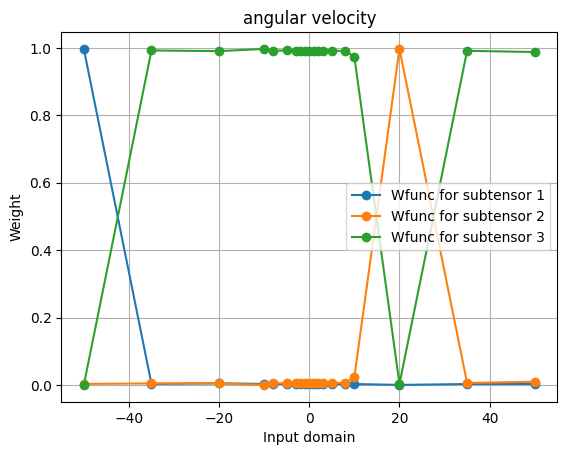

In [10]:
draw_weighting_system(Us_irno, mygrid, save=True, filename="irno_rank2")

## Now, if we keep 4 instead of 2 singular values...

In [11]:
IS_TWO_DIMENSIONAL = True

Us, S, eigvals = hosvd(aggregates, with_eigvals=True)

if IS_TWO_DIMENSIONAL:
    print(f"Singular values are: {np.diag(S)}")
    rank_to_keep = int(input("How many singular values do you want to keep?"))
    Us_tilde, S_tilde = hosvd(aggregates, rank=[rank_to_keep]*aggregates.ndim)
else:
    Us, S, eigvals = hosvd(aggregates, with_eigvals=True)
    print("Eigenvalues in each dimension:")
    for inx, eigval in enumerate(eigvals):
        print(f"Dimension {inx+1}: {eigval}")

    decision = input("""
    How many ranks to keep?
    a.)              Same rank in all dimensions
    b.)              Dimension-specific ranks
    c.)              Two ranks in all dimensions
    [anything else]) All ranks in all dimensions

    """)

    if decision == 'a':
        rank_to_keep = int(input("How many singular values do you want to keep?"))
        Us_tilde, S_tilde = hosvd(aggregates, rank=[rank_to_keep]*aggregates.ndim)
    elif decision == 'b':
        ranks_to_keep = [1 for _ in range(aggregates.ndim)]
        for inx in range(aggregates.ndim):
            ranks_to_keep[inx] = int(input(f"How many singular values to keep in dimension {inx+1}?"))
        Us_tilde, S_tilde = hosvd(aggregates, rank=ranks_to_keep)
    elif decision == 'c':
        rank_to_keep = 2
        Us_tilde, S_tilde = hosvd(aggregates, rank=[rank_to_keep]*aggregates.ndim)
    else:
        Us_tilde, S_tilde = hosvd(aggregates)

reconstructed = reconstruct(S_tilde, Us_tilde)
rmse_reconstruction = np.sqrt(np.mean((reconstructed - aggregates)**2))

r2_reconstruction = calc_R2(aggregates, reconstructed)
#c_reconstruction = calc_cindex(aggregates, reconstructed)
print(f"Reconstruction R2 is: {r2_reconstruction}")
#print(f"Reconstruction Concordance index is: {c_reconstruction}")

data_reconstructed = infer_ats(
    S_tilde, Us_tilde, mygrid, data[:,:data.shape[1]-1]
)

nrmse_mmin_dataset = calc_nRMSE_maxmin(data[:, -1].reshape(-1,1), data_reconstructed)
nrmse_iqr_dataset = calc_nRMSE_iqr(data[:, -1].reshape(-1,1), data_reconstructed)
r2_dataset = calc_R2(data[:, -1].reshape(-1,1), data_reconstructed)
c_dataset = calc_cindex(data[:, -1].reshape(-1,1), data_reconstructed)
print(f"Normalized RMSE on original data (dividing by max - min) is: {nrmse_mmin_dataset}")
print(f"Normalized RMSE on original data (dividing by interquartile range) is: {nrmse_iqr_dataset}")
print(f"R2 on original data is: {r2_dataset}")
print(f"Concordance index on original data is: {c_dataset}")


Singular values are: [-2.8517258e+08  8.1193064e+07 -2.8829596e+07 -1.4508145e+07
 -1.2349251e+07 -1.0339120e+07 -8.9297640e+06  8.2822770e+06
  3.0395455e+06  2.4805200e+06  1.4550805e+06 -6.2592981e+05
 -2.5636272e+03 -5.8555920e+02 -3.1084436e+04  1.0135222e+04
  3.7604395e+03  2.0430736e+03 -1.9589629e+02]


How many singular values do you want to keep? 4


Reconstruction R2 is: 0.9952259063720703
Normalized RMSE on original data (dividing by max - min) is: 0.0029668719158331886
Normalized RMSE on original data (dividing by interquartile range) is: 238.65387279009826
R2 on original data is: 0.9952259279548917
Concordance index on original data is: 0.8004941703343371


In [12]:
S_cno, Us_cno = to_cno(S_tilde, Us_tilde)

Distance from NO: 8.054682002300808
Distance from NO: 1.7461187502035591


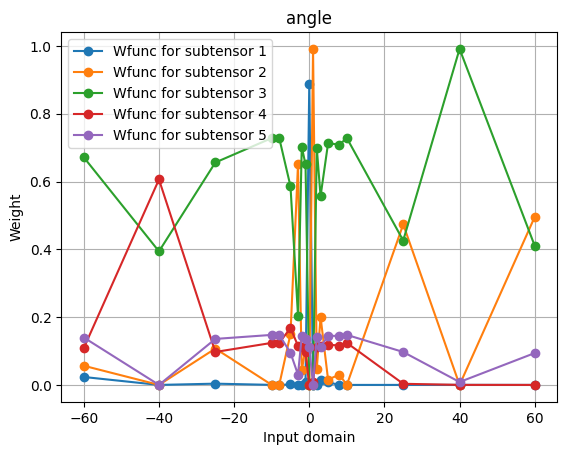

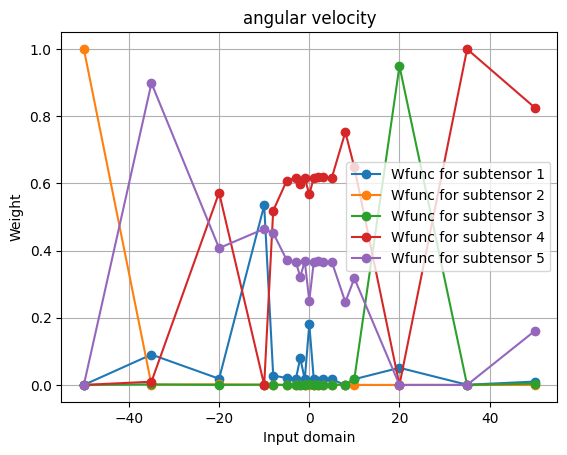

In [13]:
draw_weighting_system(Us_cno, mygrid, save=True, filename="cno_rank4")

In [14]:
S_irno, Us_irno = to_irno(S_tilde, Us_tilde)

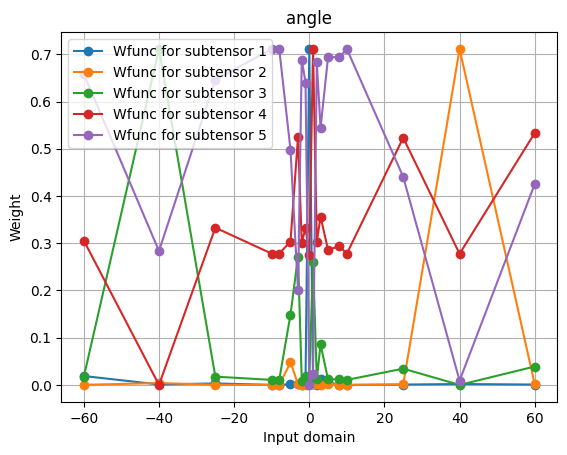

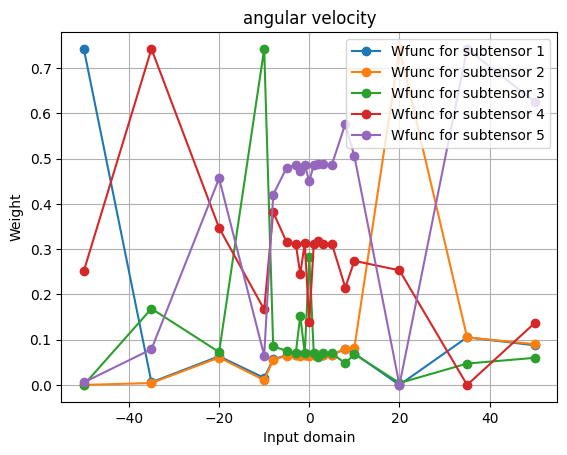

In [15]:
draw_weighting_system(Us_irno, mygrid, save=True, filename="irno_rank4")